Google Play Store Rating Prediction
This project focuses on predicting the rating of Android applications using the Google Play Store dataset. The primary objective is to build a complete machine learning pipeline, starting from data cleaning and exploratory data analysis (EDA) to feature engineering, preprocessing, model training, and evaluation.

During the project, missing values were handled, categorical and numerical features were preprocessed using Scikit-learn's `ColumnTransformer` and `Pipeline`, and new features such as `Log_Installs` were created to improve model performance. Multiple regression models, including **Linear Regression** and **Random Forest Regressor**, were trained and compared. **Hyperparameter tuning** was performed using **GridSearchCV**, and the models were evaluated using **R² Score** and **Cross-Validation**.

This project demonstrates practical skills in **Python**, **Pandas**, **NumPy**, **Matplotlib**, **Seaborn**, **Scikit-learn**, **Feature Engineering**, **Machine Learning Pipelines**, **Exploratory Data Analysis (EDA)**, and **Model Evaluation**.

**Import Libraries**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

**DATA LOAD**

In [10]:
df = pd.read_csv("data/googleplaystore.csv")

In [11]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [12]:
df.isnull().sum().sum()

np.int64(1487)

In [13]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


**Data Cleaning**

In [14]:
from sklearn.impute import SimpleImputer

In [15]:
imputer = SimpleImputer(strategy="median")
df["Rating"] = imputer.fit_transform(df[["Rating"]])

In [ ]:
#Convert Installs to numeric values
df['Installs'] = df['Installs'].replace(r'Free', np.nan, regex=True)
df["Installs"] = df["Installs"].str.replace(r"\+", "", regex=True)
df["Installs"] = df["Installs"].str.replace(r"\,", "", regex=True)


In [20]:
#Fix data types:
df["Installs"] = df["Installs"].astype(float) 

In [21]:
df["Reviews"] = df["Reviews"].replace(r"\+", "", regex=False)

In [22]:
df["Reviews"] = (df["Reviews"].str.replace('M', '', regex=False).astype(float) * 1_000_000).astype(int)

In [23]:
def parse_size(size_str):
  if pd.isna(size_str) or size_str == "Varies with device":
    return np.nan
  if "M" in size_str:
    return float(size_str.replace("M", ""))
  if "k" in size_str:
    return float(size_str.replace("k", "")) / 1024.0  # Convert KB to MB
  return np.nan


df["Size"] = df["Size"].apply(parse_size)

# Impute missing Size values with the median size
df["Size"] = df["Size"].fillna(df["Size"].median())

In [ ]:
df=df.drop(columns=['Reviews'])

In [24]:
df = df.dropna(subset=['Installs'])


*Feature Selection:*

I remove unimportant columns from the dataset

In [ ]:
#Android,gnres,last update version is not a feature that is related to the rating of the app. It is a feature that is related to the compatibility of the app with the device. So I drop it.
df=df.drop(columns=['Android Ver'])
df=df.drop(columns=['Last Updated'])

In [ ]:
df=df.drop(columns=['Current Ver'])

In [ ]:
# df.drop(columns=['Log_Installs'], inplace=True) #After find multicollinearity, I drop Log_Installs because it is highly correlated with Log_Reviews. 
df.drop(columns=['Log_Reviews'], inplace=True)   

**Exploratory Data Analysis**

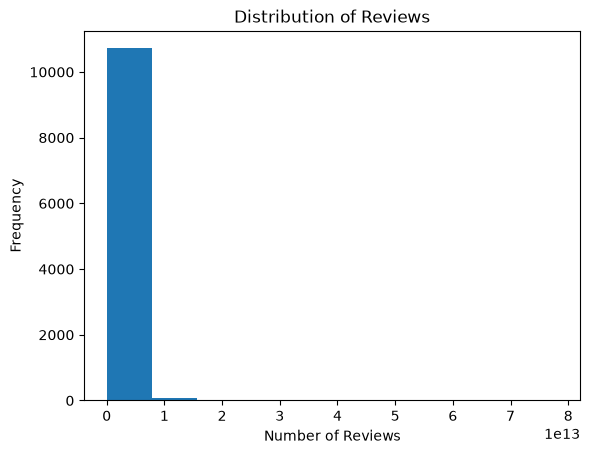

In [32]:
plt.hist(df["Reviews"])
plt.title("Distribution of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.savefig("images/Reviews_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Observation:

The Reviews feature is highly right-skewed, with most applications having relatively few reviews.
A small number of popular apps have extremely large review counts, creating a long right tail.

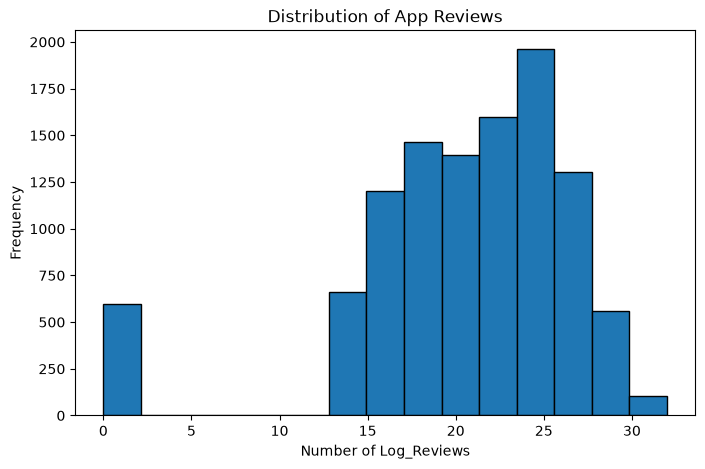

In [30]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Log_Reviews"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of App Reviews")
plt.xlabel("Number of Log_Reviews")
plt.ylabel("Frequency")
plt.savefig("images/Log_Reviews_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Observation:

Applying the logarithmic transformation reduced the skewness and produced a more balanced distribution.
The transformed feature is more suitable for machine learning because extreme values are compressed.

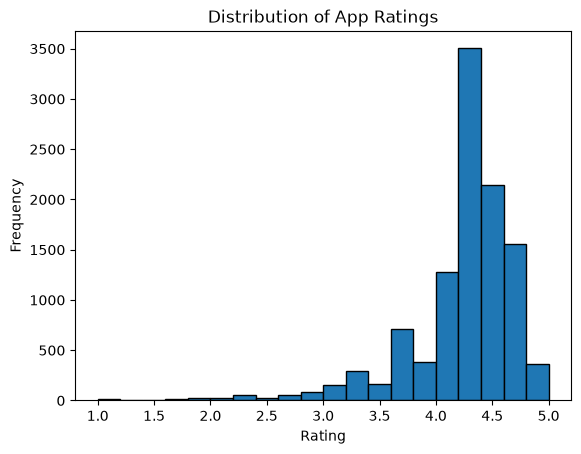

In [33]:
plt.hist(
    df["Rating"], bins=20, edgecolor='black')
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.savefig("images/Rating_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Observation:

Most applications have ratings between 4.0 and 4.5, indicating that highly rated apps dominate the dataset.
Very few applications have ratings below 3.5, making the target variable left-skewed.

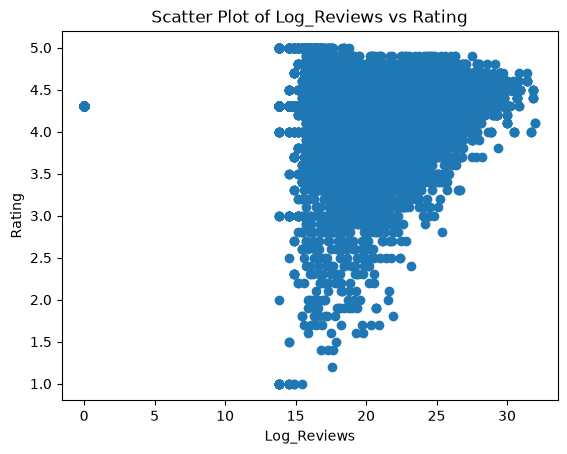

In [34]:
plt.scatter(df["Log_Reviews"], df["Rating"])
plt.title("Scatter Plot of Log_Reviews vs Rating")
plt.xlabel("Log_Reviews")
plt.ylabel("Rating")
plt.savefig("images/Log_Reviews_vs_Rating.png", 
            dpi=300, 
            bbox_inches="tight")
plt.show()

Observation:

Applications with more reviews generally tend to have higher ratings, although the relationship is weak.
The wide spread of points indicates that review count alone is not sufficient to predict app ratings.

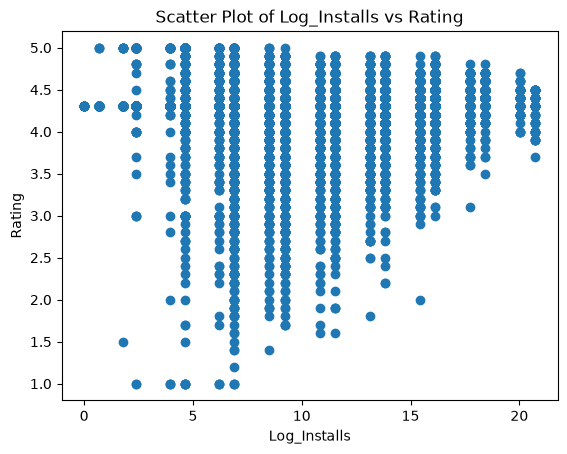

In [35]:
plt.scatter(df["Log_Installs"], df["Rating"])
plt.title("Scatter Plot of Log_Installs vs Rating")
plt.xlabel("Log_Installs")
plt.ylabel("Rating")
plt.savefig("images/Log_Installs_vs_Rating.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Observation:

Applications with higher installation counts tend to receive slightly higher ratings.
The relationship is weak, suggesting that installs alone have limited predictive power.

*BOXPLOT*

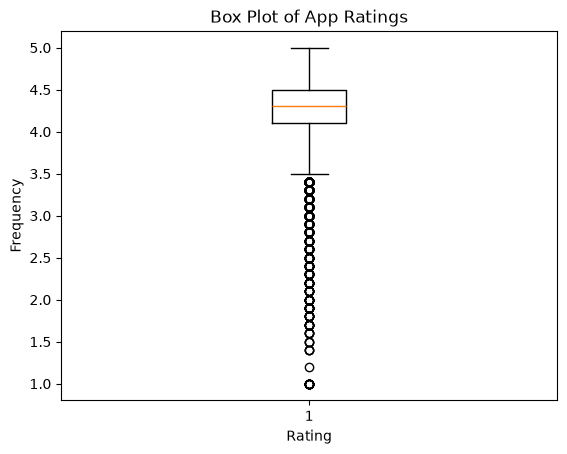

In [36]:
plt.boxplot(df["Rating"])
plt.title("Box Plot of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.savefig("images/Rating_boxplot.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Observation:

Most ratings lie between 4.1 and 4.5, with several low-rating outliers below the lower whisker.
The presence of a few poorly rated apps does not significantly affect the overall distribution.

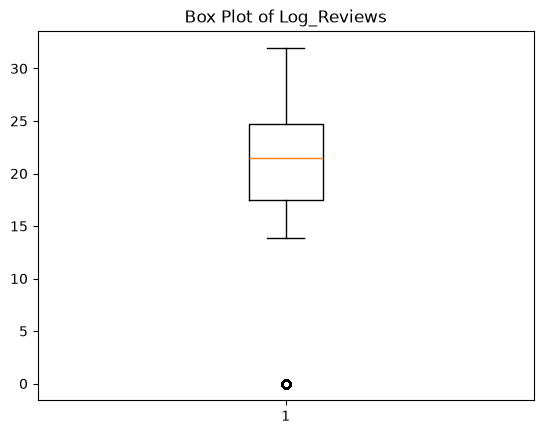

In [ ]:
plt.boxplot(df["Log_Reviews"])
plt.title("Box Plot of Log_Reviews")
plt.show()

Observation:

After log transformation, almost all review values fall within a reasonable range with only a few remaining outliers.

The transformation successfully reduced the influence of extremely large review counts.

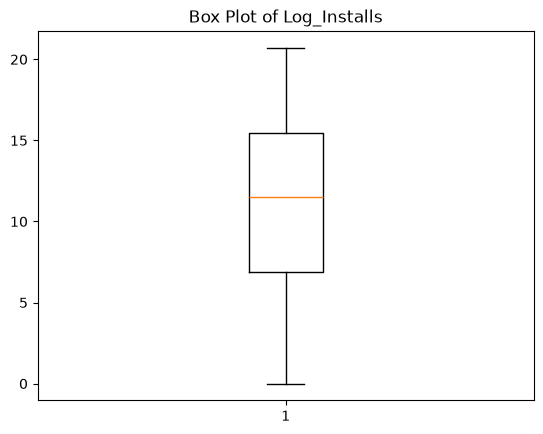

In [ ]:
plt.boxplot(df["Log_Installs"])
plt.title("Box Plot of Log_Installs")
plt.show()

Observation:

No significant outliers are observed after applying the logarithmic transformation.

The transformed installation counts are well distributed and suitable for model training.

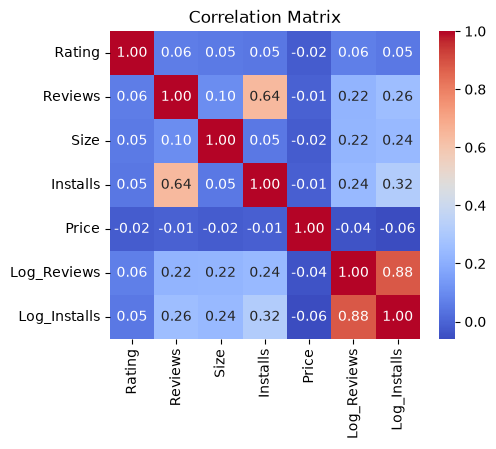

In [38]:
#Correlation Matrix visualizing using heatmap
plt.figure(figsize=(5,4))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.savefig("images/Correlation_Matrix.png",
            dpi=300)
plt.show()

Observation:

Most numerical features have only weak linear correlations with the target variable (Rating).
Size and Log_Installs show a moderate positive correlation, while Price has almost no linear relationship with app ratings.

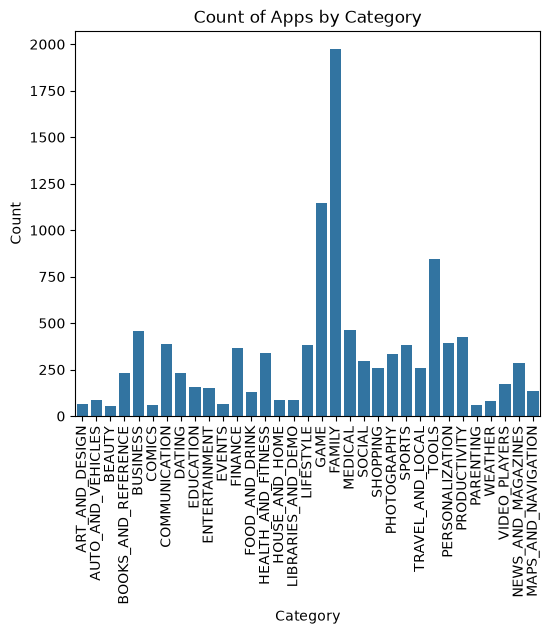

In [39]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="Category")
plt.xticks(rotation=90)
plt.title("Count of Apps by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.savefig("images/Count_of_Apps_by_Category.png",
            dpi=300)
plt.show()

Observation:

The Family category contains the highest number of applications, followed by Game and Tools.
The dataset is imbalanced across categories, with several categories containing comparatively few apps.

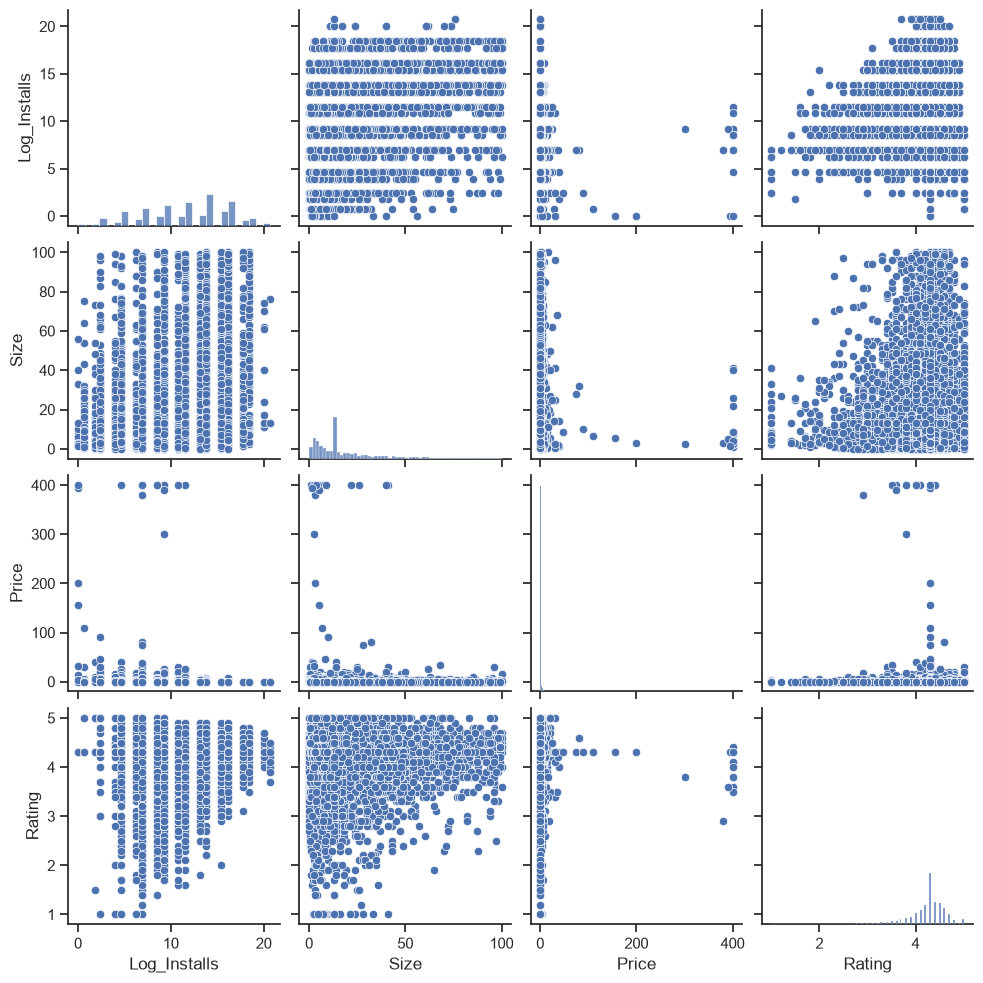

In [40]:
sns.set(style="ticks")
sns.pairplot(
    df[["Log_Installs", "Size", "Price", "Rating"]]
)
plt.savefig("images/Pairplot.png",
            dpi=300,
            bbox_inches="tight")

Observation:

The pair plot shows no strong linear relationship between the numerical features and app ratings.
It also highlights the skewed distribution of Price and the positive relationship between Size and Log_Installs.

## 🔧 Feature Engineering

To improve data quality and prepare the dataset for machine learning, the following feature engineering steps were performed:

### 📌 Created `Log_Reviews`
- The `Reviews` feature was highly positively skewed, with a few applications having extremely large review counts while most apps had relatively few reviews.
- A logarithmic transformation (`Log_Reviews`) was applied to reduce skewness, compress extreme values, and create a more balanced distribution.
- After analyzing feature correlations, the original `Reviews` column was removed because it was highly correlated with `Installs`, making it redundant.

### 📌 Created `Log_Installs`
- Similar to `Reviews`, the `Installs` feature was heavily right-skewed due to a small number of applications having millions of installs.
- A logarithmic transformation (`Log_Installs`) reduced the effect of extreme values and produced a more interpretable distribution.
- The transformed feature was retained for model training because it provided a cleaner representation of installation counts.

### 📌 Converted `Price` to Numeric
- The `Price` column was originally stored as a string containing currency symbols (e.g., `$4.99`).
- Currency symbols were removed, and the column was converted to a floating-point numeric type.
- This allowed the feature to be used as a numerical input for machine learning models.

In [27]:
#Log Transformation of Reviews
df["Log_Reviews"] = np.log1p(df["Reviews"]) ##Feature Engineering: Log Transformation of Reviews

In [28]:
#Log Transformation of Installs
df['Log_Installs'] = np.log1p(df['Installs']) #Feature Engineering: Log Transformation of Installs

In [29]:
#Price is a string, so I need to convert it to float. I will remove the '$' sign and convert it to float.
df["Price"] = df["Price"].str.replace('$', '')
df["Price"] = df["Price"].str.replace("'", '')
df["Price"] = df["Price"].astype(float)

**CORRELATION**

In [ ]:
correlation = df[['Log_Installs', 'Rating']].corr()
print(correlation)

              Log_Installs    Rating
Log_Installs      1.000000  0.049059
Rating            0.049059  1.000000


In [ ]:
num_df = df.select_dtypes(include=[np.number])

In [ ]:
num_df.columns

Index(['Rating', 'Size', 'Price', 'Log_Reviews', 'Log_Installs'], dtype='str')

In [ ]:
corr_matrix = num_df.corr()
corr_matrix

,Rating,Size,Price,Log_Reviews,Log_Installs
Rating,1.000000,0.053450,-0.019318,0.064403,0.049059
Size,0.053450,1.000000,-0.019372,0.222938,0.240070
Price,-0.019318,-0.019372,1.000000,-0.041393,-0.060498
Log_Reviews,0.064403,0.222938,-0.041393,1.000000,0.883539
Log_Installs,0.049059,0.240070,-0.060498,0.883539,1.000000


Log_Reviews ↔ Log_Installs: 0.883
These variables move together, very strongly

**Data Preprocessing**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop("Rating", axis=1), df["Rating"], test_size=0.2, random_state=42)


In [ ]:
X_train.select_dtypes(include="object").columns


C:\Users\DELL\AppData\Local\Temp\ipykernel_13148\491807120.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train.select_dtypes(include="object").columns


Index(['Category', 'Type', 'Content Rating', 'Genres', 'Current Ver'], dtype='str')

In [ ]:
numeric_cols = ["Log_Installs", "Size","Price"]


In [ ]:
categorical_cols = X_train.select_dtypes(include="object").columns

C:\Users\DELL\AppData\Local\Temp\ipykernel_13148\3916943964.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns


In [ ]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
#Using ColumnTransformer to apply different preprocessing steps to numeric and categorical columns.
preprocessor = ColumnTransformer(
    transformers=[
        ("nums", num_pipeline, numeric_cols),
        ("cats", cat_pipeline, categorical_cols)
    ]
)

## 🤖 Model Building

### Linear Regression

A Linear Regression model was initially trained as a baseline model. However, it achieved a low R² score, indicating that it was unable to capture the relationship between the selected features and app ratings effectively.

### Random Forest Regressor

Since the dataset exhibited non-linear relationships, a Random Forest Regressor was trained next. Hyperparameter tuning using GridSearchCV was performed to improve generalization and reduce overfitting.

**Results**
- Train R²: 0.19
- Test R²: 0.09

**Conclusion**

Although the overall R² score remained modest, Random Forest outperformed Linear Regression and generalized better after hyperparameter tuning. The results also suggest that the available features have only a weak relationship with app ratings, limiting the model's predictive performance.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=4

    ))
])

**Hyperparameter Tuning**

*GridSearchCV*


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "regressor__n_estimators": [20, 50, 100],
    "regressor__max_depth": [3, 5, 7, 10],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4]
}

In [ ]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__max_depth': [3, 5, ...], 'regressor__min_samples_leaf': [1, 2, ...], 'regressor__min_samples_split': [2, 5, ...], 'regressor__n_estimators': [20, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.

In [ ]:
print(grid.best_params_)

{'regressor__max_depth': 10, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 100}


**BEST PARAMETERS**: _{'regressor__max_depth': 10, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 100}_


In [ ]:
best_model = grid.best_estimator_

print("Train R²:", best_model.score(X_train, y_train))
print("Test R² :", best_model.score(X_test, y_test))
print("Best CV :", grid.best_score_)

Train R²: 0.18947949331552894
Test R² : 0.08925897734314137
Best CV : 0.08167879301450542


Here we can see the Improvement in our model after HyperParameter Tuning:

Train R²: 0.18947949331552894

Test R² : 0.08925897734314137

Best CV : 0.08167879301450542

In [ ]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Category','Size','Type',...,'Genres','Current Ver','Log_Installs']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nums', ...), ('cats', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of column

In [ ]:
y_pred = model.predict(X_test)

### Model Evaluation

The tuned Random Forest model achieved an **R² score of 0.089**, indicating that the available features explain only a small portion of the variation in app ratings.

The **Mean Absolute Error (MAE) of 0.297** shows that, on average, the predicted rating differs from the actual rating by approximately **0.30 rating points**. The **Mean Squared Error (MSE) of 0.198** indicates a relatively low average squared prediction error.

Although the overall predictive performance is modest, the model outperformed the baseline Linear Regression model and demonstrated better generalization after hyperparameter tuning.

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = best_model.predict(X_test)

print("R² :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² : 0.08925897734314137
MAE: 0.2974452777198447
MSE: 0.19841893552495737


**Conclusion**

Although the overall R² score remained modest, Random Forest outperformed Linear Regression and generalized better after hyperparameter tuning. The results also suggest that the available features have only a weak relationship with app ratings, limiting the model's predictive performance.